In [1]:
import cv2 as cv
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator as imgen
from tensorflow.keras import datasets
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Conv2D, MaxPooling2D,Flatten , Dropout,BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [2]:
train_dir = './dataset/cat_and_dog/training_set'
valid_dir = './dataset/cat_and_dog/test_set'

In [3]:
model = Sequential([
    Input(shape=(224,224,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

In [4]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Found 8005 images belonging to 2 classes.
Found 2024 images belonging to 2 classes.


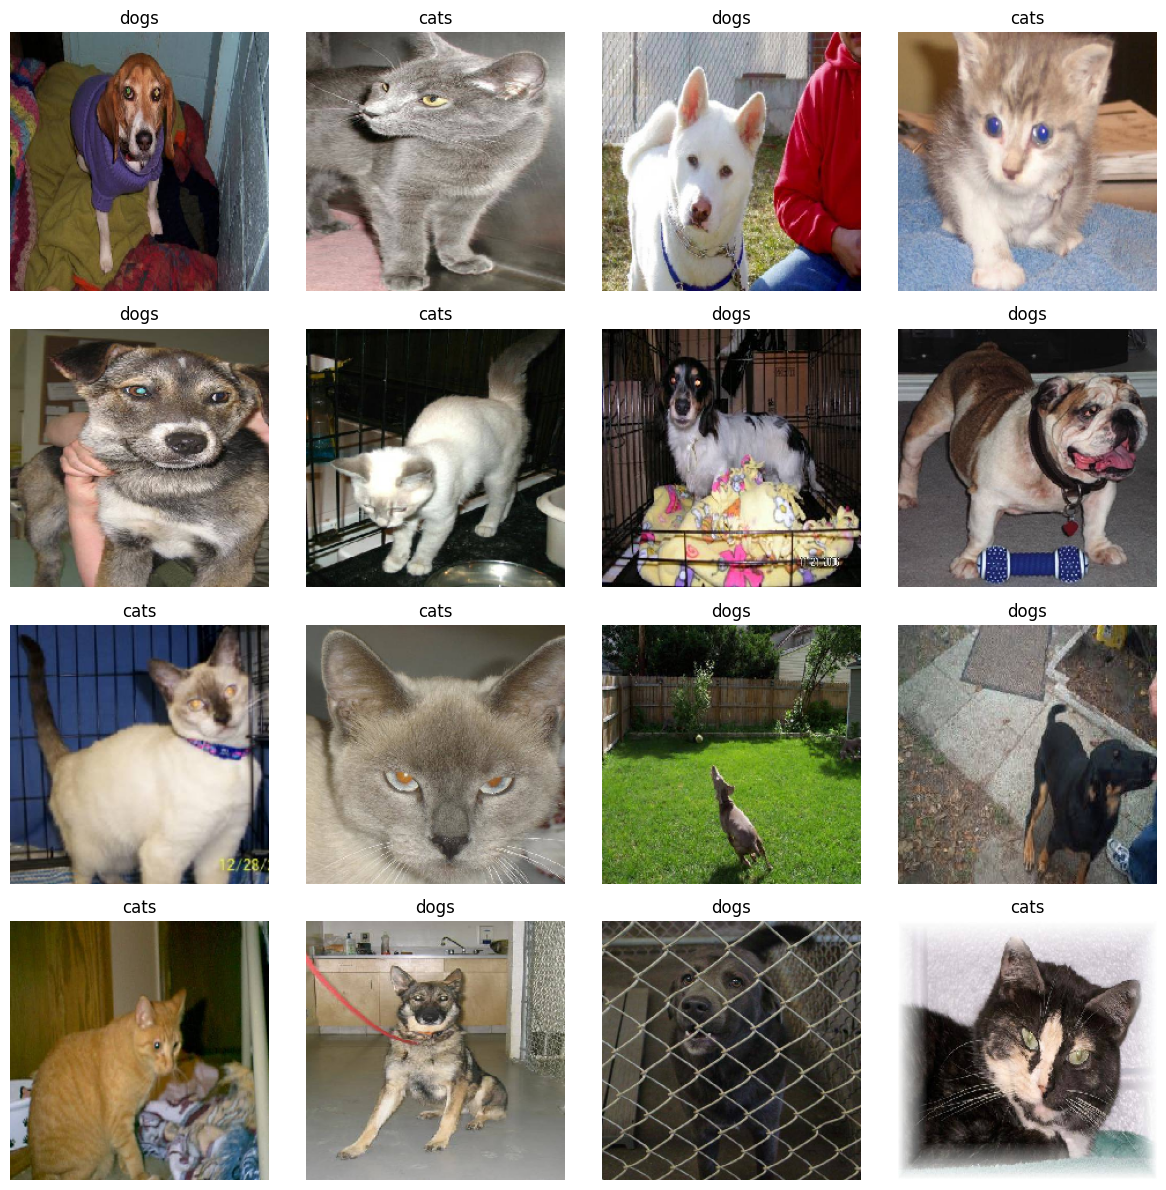

Epoch 1/5
501/501 [==============================] - 20s 33ms/step - loss: 0.7552 - accuracy: 0.4997 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 2/5
501/501 [==============================] - 16s 32ms/step - loss: 0.6932 - accuracy: 0.5077 - val_loss: 0.6599 - val_accuracy: 0.6107
Epoch 3/5
501/501 [==============================] - 16s 32ms/step - loss: 0.6637 - accuracy: 0.5744 - val_loss: 0.6690 - val_accuracy: 0.5820
Epoch 4/5
501/501 [==============================] - 16s 31ms/step - loss: 0.6275 - accuracy: 0.6381 - val_loss: 0.5633 - val_accuracy: 0.7090
Epoch 5/5
501/501 [==============================] - 16s 32ms/step - loss: 0.5266 - accuracy: 0.7425 - val_loss: 0.5063 - val_accuracy: 0.7604


In [5]:
# 1. ImageDataGenerator
image_gen = imgen(rescale=1/255.0)

# 2. Generators
train_gen = image_gen.flow_from_directory(
    train_dir,
    batch_size=16,
    target_size=(224,224),
    classes=['cats','dogs'],
    class_mode='binary',
    seed=2026
)
valid_gen = image_gen.flow_from_directory(
    valid_dir,
    batch_size=16,
    target_size=(224,224),
    classes=['cats','dogs'],
    class_mode='binary',
    seed=2026
)

# 3. 배치 시각화
class_name = ['cats','dogs']
batch = next(train_gen)
image, labels = batch[0], batch[1]

plt.figure(figsize=(12,12))
for i in range(16):
    ax = plt.subplot(4,4,i+1)
    plt.imshow(image[i])
    plt.title(class_name[int(labels[i])])
    plt.axis('off')
plt.tight_layout()
plt.show()

# 4. 모델
model = Sequential([
    Input(shape=(224,224,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# 5. 컴파일
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6. 학습
history = model.fit(train_gen, validation_data=valid_gen, epochs=5)

In [6]:
import matplotlib.pyplot as plt

def plot_loss_acc(history, epochs):
    # Keras History 객체에서 값 가져오기
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss 그래프
    axes[0].plot(range(1, epochs+1), loss, label='Training')
    axes[0].plot(range(1, epochs+1), val_loss, label='Validation')
    axes[0].legend(loc='best')
    axes[0].set_title('Loss')

    # Accuracy 그래프
    axes[1].plot(range(1, epochs+1), acc, label='Training')
    axes[1].plot(range(1, epochs+1), val_acc, label='Validation')
    axes[1].legend(loc='best')
    axes[1].set_title('Accuracy')

    plt.show()

# 데이터 증강 (Data Augmentation)

In [ ]:
image_gen = imgen(
    rescale=1/255.0,
    horizontal_flip=True,
    rotation_range=35,
    zoom_range=0.2
)

# 2. Generators
train_gen = image_gen.flow_from_directory(
    train_dir,
    batch_size=32,
    target_size=(224,224),
    classes=['cats','dogs'],
    class_mode='binary',
    seed=2026
)

valid_gen = image_gen.flow_from_directory(
    valid_dir,
    batch_size=32,
    target_size=(224,224),
    classes=['cats','dogs'],
    class_mode='binary',
    seed=2026
)

# 3. 모델
model = Sequential([
    Input(shape=(224,224,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.summary()

# 4. 컴파일
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. 학습
history = model.fit(train_gen, validation_data=valid_gen, epochs=5)

Found 8005 images belonging to 2 classes.
Found 2024 images belonging to 2 classes.
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 batch_normalization_2 (Batc  (None, 224, 224, 3)      12        
 hNormalization)                                                 
                                                                 
 conv2d_6 (Conv2D)           (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 111, 111, 32)     0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 54, 54, 64)       0         
 2D)                                

In [ ]:
# 6. 예측

from tensorflow.keras.preprocessing import image

img_path = 'dataset/cat_and_dog/cat_02.jpg'

img = image.load_img(img_path,target_size=(224,224))
img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor,axis=0)
img_tensor = img_tensor/255.0

pred = model.predict(img_tensor)
plt.imshow(img)
plt.axis('off')

if pred[0]>0.5:
    r = f'dog(result:{pred[0][0]*100:.2f}%)'
else:
    r = f'cat(result:{1-pred[0][0]*100:.2f}%)'

plt.title(r)
plt.show()